In [ ]:
# PRADA against benchmarker shapemapper --- --- 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
from Bio import SeqIO
from sklearn import metrics  

In [ ]:
## 1. Extend Figure 4p --- --- 

In [3]:
coord = pd.read_csv('./Data/mitochondria_coordinates.csv',sep=',')

In [4]:
def get_AUROC_against_shapemap(gene,transcript):

    ### A. get the bench files --- --- 

    dir = "./Data/"
    bench = pd.read_csv(dir+"HAstV1_Caco2_NC_012920.1_profile.txt",sep='\t')
    bench = bench[(bench['Modified_effective_depth'] >=5000) & (bench['Untreated_effective_depth'] >=5000)]

    start = coord.loc[coord['Gene']==transcript, 'Start'].values[0]
    end = coord.loc[coord['Gene']==transcript, 'End'].values[0]
    mtgene = bench[(bench['Nucleotide']>=start) & (bench['Nucleotide']<=end)]
    mtgene=mtgene[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
    mtgene['Nucleotide']=mtgene['Nucleotide']-start+1 
    flt = mtgene.dropna() 
    cutoff1=0.85
    cutoff2=0.4
    tmp1 = flt[flt['Norm_profile']>=cutoff1]
    tmp1['strand'] = 1
    tmp2 = flt[flt['Norm_profile']<=cutoff2]
    tmp2['strand'] = 0
    bench=pd.concat([tmp1,tmp2]) 


    ### B. combine the PRADA with bench shapemapper  --- 

    dir = "./Data/"
    vitro = pd.read_csv(dir+'vitro_heavy_NC_012920.1_profile.txt',sep='\t')
    vitro = vitro[(vitro['Modified_effective_depth'] >=5000) & (vitro['Untreated_effective_depth'] >=5000)]

    start = coord.loc[coord['Gene']==transcript, 'Start'].values[0]
    end = coord.loc[coord['Gene']==transcript, 'End'].values[0]
    mtgene = vitro[(vitro['Nucleotide']>=start) & (vitro['Nucleotide']<=end)]
    mtgene=mtgene[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
    mtgene['Nucleotide']=mtgene['Nucleotide']-start+1

    df = pd.merge(bench,mtgene, how='inner',on=['Nucleotide','Nucleotide'])
    flt=df[(df['Sequence_x']=='T') | (df['Sequence_x']=='G') | (df['Sequence_x']=='U')]

    flt.to_csv('./Data/'+'source_data_Efig6f.csv',sep=',')

    ### C. plot the AUROC  --- 

    fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile_y, pos_label=1)
    roc_auc_1 = metrics.auc(fpr_1, tpr_1)
    print(roc_auc_1)

    fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
        ax.tick_params(width = 2)
        
    plt.title("Against SHAPE-MaP in vitro \n"+ transcript+'\n (UG '+str(flt.shape[0])+' positions)', fontsize = 25)
    plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

    plt.legend(loc = 'lower right', fontsize = 18)
    plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate', fontsize = 20)
    plt.xlabel('False Positive Rate', fontsize = 20)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)

    dir_out = "./Data/"
    plt.savefig(dir_out+'Extend_Fig6f_PRADA_COX1_AUROC_against_shapemapper.pdf',bbox_inches='tight', dpi=300)

/tmp/ipykernel_11404/2739130469.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['strand'] = 1
/tmp/ipykernel_11404/2739130469.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['strand'] = 0


0.7101933529359351


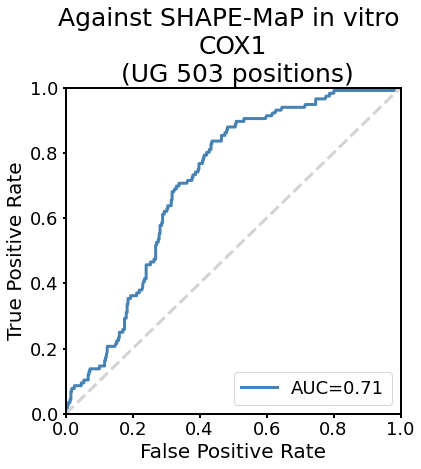

In [5]:
get_AUROC_against_shapemap('COX1','COX1')